## **Brewster Tutorial 3: Creating a multiple instrument  R-file**

This notebook is split into two parts, the first half is a tutorial for creating an R file for JWST data (spectroscopy) and the second half creates an R file for SPHEREx data (photometry). At the very end is a portion for combining the two, if using combined data in a retrieval. This is a reworked version of the original R file notebook, as this introduces a fifth column in the R file (conv_mode) which will activate the spectroscopic resolution or photometric bandwidth mode during the forward model's convolution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
from scipy import interpolate
from astropy.io import fits
from astropy.table import Table, QTable
from astropy.io import ascii

Example of an R-file that contains both photometric and spectroscopic data.

In [ ]:

# resolution/band width wavelength logf_flag scales conv_mode
#          50             0.805       1.0     0.0      0.0     # JWST data
#          50              0.81       1.0     0.0      0.0     # JWST data
#          50             0.815       1.0     0.0      0.0     # JWST data
#          50              0.82       1.0     0.0      0.0     # JWST data
#       0.018             0.824       1.0     0.0      1.0     # SPHEREx data
#       0.018             0.833       1.0     0.0      1.0     # SPHEREx data
#       0.018             0.842       1.0     0.0      1.0     # SPHEREx data
#       0.018             0.851       1.0     0.0      1.0     # SPHEREx data
#          50             0.855       1.0     0.0      0.0     # JWST data
#          50              0.86       1.0     0.0      0.0     # JWST data


# Spectroscopic R File

Creating an R file for spectroscopy data that uses resolution, eg. JWST data

In [ ]:
# loading in JWST data

with fits.open('GJ499Cjwst.fits') as jwstdata:
    raw = pd.DataFrame(jwstdata[1].data)

drop_cols = [
    'FLUX_VAR_POISSON', 'FLUX_VAR_RNOISE', 'FLUX_VAR_FLAT',
    'SURF_BRIGHT', 'SB_ERROR', 'SB_VAR_POISSON', 'SB_VAR_RNOISE',
    'SB_VAR_FLAT', 'DQ', 'BACKGROUND', 'BKGD_ERROR',
    'BKGD_VAR_POISSON', 'BKGD_VAR_RNOISE', 'BKGD_VAR_FLAT', 'NPIXELS'
]

raw = raw.drop(
    columns=[c for c in drop_cols if c in raw.columns]
).dropna()

flux = raw['FLUX']            # Jy
flux_err = raw['FLUX_ERROR']

ang = raw['WAVELENGTH'] * (10 ** 4)
ang_sq = ang ** 2

new_flux = (2.996e-5) * (flux / ang_sq)
new_flux_err = (2.996e-5) * (flux_err / ang_sq)

jwst_data = pd.DataFrame({
    'wavelength': raw['WAVELENGTH'].values,
    'flux': (new_flux * 10).values,
    'flux_err': (new_flux_err * 10).values,
})

jwst_data = jwst_data.iloc[::-1]

In [ ]:
jwst_data

,wavelength,flux,flux_err
385,3.460382,7.699231e-16,2.249899e-17
384,3.749455,6.348401e-16,1.293329e-17
383,3.899087,5.686721e-16,1.128950e-17
382,4.009647,5.246923e-16,9.929369e-18
381,4.111835,4.510474e-16,8.793300e-18
...,...,...,...
4,13.945775,4.670979e-18,2.355900e-18
3,13.959735,6.581662e-18,3.054792e-18
2,13.973679,5.888833e-18,2.588698e-18
1,13.987607,1.442737e-17,2.944870e-18


In [ ]:
# instrument function from prior notebook

def instrument_R(wl):

    '''Function that provides the Resolving Power (R) as a function of wavelength (wl) in micron
       with flags for the tolerance param and scale param,
       depending on jwst instrument'''

    if slit_limited == 1.0 and source_limited == 0.0:

        R = wl/(d_wl * resel_slit_lim)

        log_f_param = np.ones_like(R)

        scale_param = np.zeros_like(R)

        return R, wl, log_f_param, scale_param


    elif source_limited == 1.0 and slit_limited == 0.0:

        theta_lambda = (648000/np.pi) * 1.028 * (wl/D) #FWHM in arcsec


        R = wl / (d_wl * (theta_lambda / theta_pix))

        log_f_param = np.ones_like(R)

        scale_param = np.zeros_like(R)

        return R, wl, log_f_param, scale_param


    elif source_limited == 1.0 and slit_limited == 1.0:

        ### nirspec

        nirspec_wl = wl[(wl >= nirspec_wl_range[0]) & (wl <= nirspec_wl_range[1])]

        nirspec_d_wl = d_wl[(wl >= nirspec_wl_range[0]) & (wl <= nirspec_wl_range[1])]

        R_nirspec = nirspec_wl/(nirspec_d_wl * resel_slit_lim)

        theta_lambda_nirspec = (648000/np.pi) * 1.028 * (nirspec_wl/D)
        #print('theta_lambda_nirspec', theta_lambda_nirspec)

        log_f_param_nirspec = np.ones_like(R_nirspec)

        scale_param_nirspec = np.zeros_like(R_nirspec)



        ### miri

        miri_wl = wl[(wl >= miri_wl_range[0]) & (wl <= miri_wl_range[1])]

        miri_d_wl = d_wl[(wl >= miri_wl_range[0]) & (wl <= miri_wl_range[1])]

        theta_lambda = (648000/np.pi) * 1.028 * (miri_wl/D)
        #print('theta_lambda_miri', theta_lambda)

        R_miri = miri_wl / (miri_d_wl * (theta_lambda / theta_pix))
        #print(np.shape(R_miri),np.shape(R_nirspec))

        log_f_param_miri = np.full_like(R_miri, 2)

        if scale == 0.0:
            scale_param_miri = np.zeros_like(R_miri)
        else:
            scale_param_miri = np.ones_like(R_miri)


        #plt.plot(nirspec_wl,R_nirspec)
        #plt.plot(miri_wl,R_miri)

        return np.concatenate((R_nirspec, R_miri)), np.concatenate((nirspec_wl, miri_wl)), np.concatenate((log_f_param_nirspec, log_f_param_miri)), np.concatenate((scale_param_nirspec, scale_param_miri))

    else:

        print('Error: incorrect values given for source_limited and slit_limited.')



In [ ]:
wl = jwst_data['wavelength'].to_numpy()  #lambda in microns

d_wl = np.zeros(len(wl))
d_wl[1:-1] = (wl[2:] - wl[:-2]) / 2
d_wl[0] = wl[1] - wl[0]
d_wl[-1] = wl[-1] - wl[-2]



##### Slit limited parameters

slit_limited = 1.0  #1.0 yes, 0.0 no

resel_slit_lim = 2.2 # resolution element in case of slit limited, i.e. number of pixels per resolution



##### Source limited parameters

source_limited = 1.0 #1.0 yes, 0.0 no

D = 6.5e+6  #mirror size in micrometers

theta_pix = 0.11 #angular size of pixel



##### Both nirspec miri


nirspec_wl_range = [0.0, 4.634954929351806641e+0]  #the wavelength range of the nirspec data in micron

miri_wl_range = [3.460382, 14.0]


scale = 0.0

In [ ]:
R, wavelengths, log_f, scale = instrument_R(wl)

conv_mode = np.zeros_like(R)
print(np.shape(R))
print(np.shape(wavelengths))
print(np.shape(log_f))
print(np.shape(scale))
#print(np.array([R, wavelengths,log_f, scale, conv_mode]).T)
spec_rfile = (np.array([R, wavelengths,log_f, scale, conv_mode]))
print(np.column_stack((R, wavelengths, log_f, scale, conv_mode)))
print(np.mean(R))
print(np.max(R))

(256,)
(256,)
(256,)
(256,)
[[  5.44120365   3.46038246   1.           0.           0.        ]
 [  7.76968389   3.74945474   1.           0.           0.        ]
 [ 13.62307789   3.89908695   1.           0.           0.        ]
 ...
 [189.52616468  11.94931889   2.           0.           0.        ]
 [189.98952894  11.9670887    2.           0.           0.        ]
 [190.44490619  11.9848156    2.           0.           0.        ]]
123.64629516861186
190.44490619197302


In [ ]:
spec_rfile = spec_rfile.T
# save produced R file if just using spectroscopic data

#np.savetxt('___rfile.txt', spec_rfile)

<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_19092/928079806.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel(f"Wavelength [$\mu$m]")


Text(0, 0.5, 'Resolving Power')

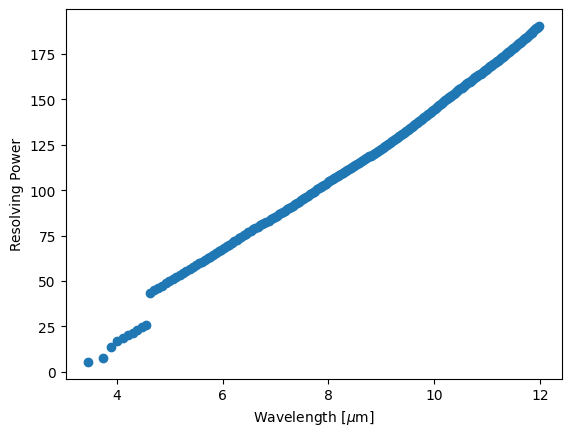

In [ ]:
plt.scatter(wavelengths, R)
plt.xlabel(f"Wavelength [$\mu$m]")
plt.ylabel('Resolving Power')

# Photometric Data R File

Creating an R file for photometric data, which will use band width instead of resolution for convolution, eg. SPHEREx


In [ ]:
# Tutorial for converting and saving SPHEREx data into an appropriate file for usage with Brewster

fulltab = pd.read_csv('/content/GJ499C.csv')
tab = fulltab[['lambda','lambda_width', 'flux', 'flux_err']]
tab

,lambda,lambda_width,flux,flux_err
0,0.746507,0.017288,40.708687,33.106740
1,0.750661,0.018102,53.230347,33.997227
2,0.753492,0.018156,-42.839905,27.891190
3,0.755966,0.017617,34.702568,29.693306
4,0.758860,0.017645,10.635584,33.520172
...,...,...,...,...
429,4.975920,0.037484,2025.005700,175.320470
430,4.984867,0.036368,2076.210400,196.231100
431,4.985566,0.037140,1942.230500,174.181490
432,4.987278,0.036705,2034.019800,203.640240


In [ ]:
data = np.genfromtxt('/content/GJ499C.csv', delimiter=',', dtype = float, skip_header=1)

wl = [row[13] for row in data]
bw = [row[14] for row in data]
flux = [row[15] for row in data]
err = [row[16] for row in data]

In [ ]:
# Converting flux units

from astropy import units as u

wl = wl * u.micron
flux = flux * u.uJy

cflux = flux.to(((u.W) / ((u.m**2) * (u.micron))), equivalencies = u.spectral_density(wl))

# Converted flux
#print ('flux (Wm^-2um^-1):',cflux)

flux (Wm^-2um^-1): [ 2.18998016e-16  2.83199076e-16 -2.26209938e-16  1.82044417e-16
  5.53680000e-17 -1.03279384e-16 -8.14930795e-17 -7.30076094e-17
  2.84874093e-16  1.74403278e-16  2.35715509e-16  4.07386668e-16
  6.41312636e-17  1.24492081e-16  3.30815312e-16  4.30174270e-16
  4.27837884e-16  5.94128684e-16  4.98048434e-16  5.39549476e-16
  5.61814262e-16  6.85103319e-16  7.07689228e-16  5.74061659e-16
  8.02927183e-16  5.18171569e-16  7.13484834e-16  5.73381072e-16
  8.25373785e-16  6.79232276e-16  5.50521050e-16  4.36836947e-16
  5.70089437e-16  5.58570016e-16  6.96590435e-16  5.19168380e-16
  7.84930847e-16  8.25716032e-16  7.81924700e-16  9.97354288e-16
  9.76594810e-16  1.07662680e-15  1.02977644e-15  1.26404953e-15
  1.60003196e-15  1.40813410e-15  1.22837666e-15  1.70353503e-15
  1.42823429e-15  1.39684338e-15  1.54231967e-15  1.48861265e-15
  1.78730030e-15  1.83643563e-15  1.42970196e-15  1.68283398e-15
  1.29193596e-15  1.39020796e-15  1.22432337e-15  1.46860216e-15
  1.51

In [ ]:
# Converting flux error units
error = err * u.uJy

cerror = error.to(((u.W) / ((u.m**2) * (u.micron))), equivalencies = u.spectral_density(wl))

# Converted flux error
#print ('flux error (Wm^-2um^-1):',cerror)

flux error (Wm^-2um^-1): [1.78102290e-16 1.80873953e-16 1.47275405e-16 1.55766587e-16
 1.74503336e-16 1.44497631e-16 1.46023673e-16 1.32129356e-16
 1.59838411e-16 1.56940469e-16 1.49674110e-16 1.65656682e-16
 1.48017020e-16 1.46605192e-16 1.41981986e-16 1.40692123e-16
 1.36301465e-16 1.31371904e-16 1.51785827e-16 1.45037825e-16
 1.27282348e-16 1.43983024e-16 1.36045588e-16 1.49572428e-16
 1.34237487e-16 1.28000235e-16 1.33768810e-16 1.43945537e-16
 1.28326605e-16 1.34234007e-16 1.24868138e-16 1.23838433e-16
 1.13281154e-16 1.39498637e-16 1.15513076e-16 1.26375734e-16
 1.25435160e-16 1.30786397e-16 1.22049557e-16 1.25675489e-16
 1.34972960e-16 1.52467001e-16 1.17087242e-16 1.36284137e-16
 1.30147408e-16 1.48400446e-16 1.29809641e-16 1.31342322e-16
 1.21077134e-16 1.41262431e-16 1.25559444e-16 1.30705274e-16
 1.27090937e-16 1.37032219e-16 1.17928006e-16 1.17349492e-16
 1.14855698e-16 1.25683620e-16 1.15240260e-16 1.14047052e-16
 1.11351477e-16 1.24931639e-16 1.22462044e-16 1.16991026e-16

In [ ]:
# Create Table of values
t = QTable([wl, cflux, cerror], names =('Central wavelength (microns)', 'Flux (Wm^-2um^-1)','Flux Error(Wm^-2um^-1)'))

# Save wavelength, converted flux, and converted flux error as a txt file
#ascii.write(t, 'GJ499C_example.txt', format='fixed_width', delimiter =' ', overwrite=True) #comment out if successful


In [ ]:
log_f_param = np.ones_like(bw)
scales_param = np.zeros_like(bw)
conv_mode_param = np.ones_like(bw) # activates the photometric convolution mode

print(np.array([bw, wl, log_f_param, scales_param, conv_mode_param]).T)

# save produced R file if just using photometric data

#np.savetxt('___rfile.txt', np.array([bw, pwl, log_f_param, scales_param, conv_mode_param]).T)

phot_rfile = np.array([bw, wl, log_f_param, scales_param, conv_mode_param])

[[0.0172877  0.74650687 1.         0.         1.        ]
 [0.01810223 0.7506614  1.         0.         1.        ]
 [0.01815567 0.7534922  1.         0.         1.        ]
 ...
 [0.03713998 4.985566   1.         0.         1.        ]
 [0.03670463 4.9872775  1.         0.         1.        ]
 [0.03687012 4.997609   1.         0.         1.        ]]


Combining R files for multiple instruments, eg. JWST and SPHEREx into a singular r file.

In [ ]:
# Combining the arrays
combined_rfile = np.hstack((phot_rfile, spec_rfile)) # arrange in order of increasing wavelength

print(combined_rfile.T)


[[2.18823563e-02 7.44000000e-01 1.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [2.18823563e-02 7.65882356e-01 1.00000000e+00 0.00000000e+00
  1.00000000e+00]
 [2.18823563e-02 7.87764713e-01 1.00000000e+00 0.00000000e+00
  1.00000000e+00]
 ...
 [1.89526165e+02 1.19493189e+01 2.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.89989529e+02 1.19670887e+01 2.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [1.90444906e+02 1.19848156e+01 2.00000000e+00 0.00000000e+00
  0.00000000e+00]]


In [ ]:
spec_rfile.shape

(5, 256)

In [ ]:
phot_rfile.shape

(5, 64)

Saving combined R file.

In [ ]:
#np.savetxt('____.txt',combined_rfile.T)